In [2]:
import seaborn as sns
from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(
    n_samples = 1000,
    n_features = 2,
    centers = 4,
    random_state = 42
)

<Axes: >

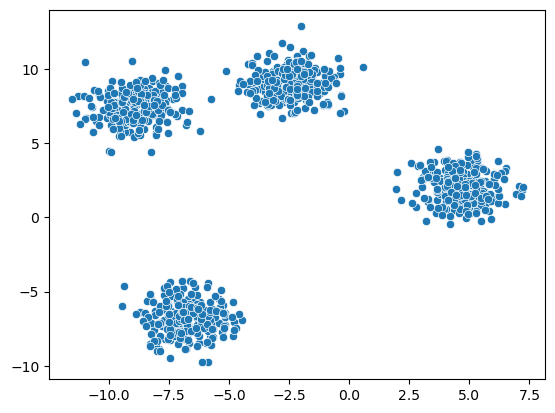

In [4]:
# Visualize the data 

sns.scatterplot(x=X[:,0], y=X[:, 1])

In [5]:
from sklearn.cluster import KMeans

In [6]:
k = 4

kmeans = KMeans(
    n_clusters = k,
    random_state = 42
)

In [7]:
labels = kmeans.fit_predict(X)

<Axes: >

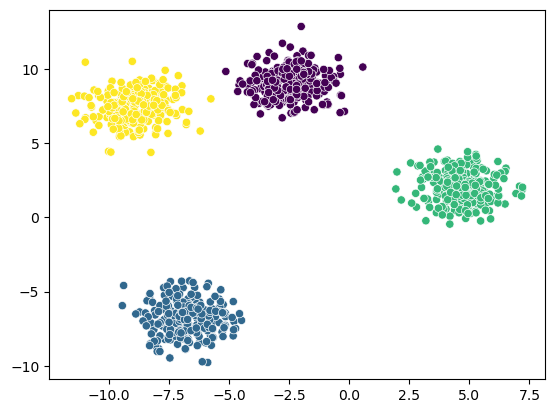

In [8]:
sns.scatterplot(x=X[:,0], y=X[:, 1], c = labels)

### choose out k values elbow; silhoutte score

In [10]:
# Elbow method 

wcss = []

for k in range(1, 21):
    kmeans= KMeans(n_clusters = k)
    kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)



<Axes: >

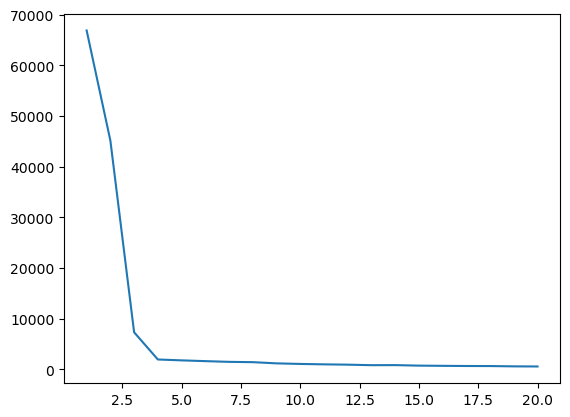

In [11]:
sns.lineplot(x = range(1, 21), y= wcss)

In [12]:
# kneed module

!pip install kneed

In [13]:
from kneed import KneeLocator

In [14]:
knee = KneeLocator(range (1, 21), wcss, curve = "convex", direction = "decreasing")

In [15]:
print("optimak k : ", knee.elbow)

optimak k :  4


### Sillhoutte Score 

In [17]:
from sklearn.metrics import silhouette_score

In [18]:
ss = []

for k in range(2, 21):
    kmeans = KMeans(n_clusters = k)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    ss.append(score)


<Axes: >

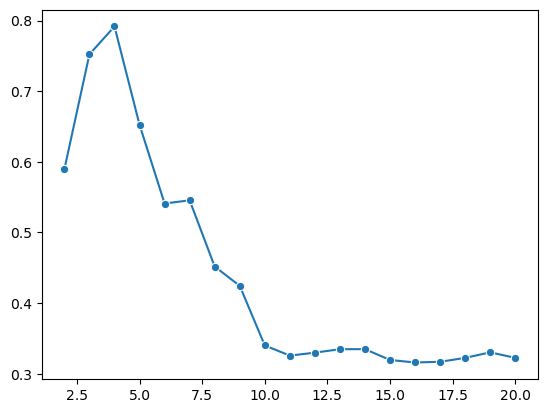

In [19]:
# plot k and ss 

sns.lineplot(x=range(2, 21), y=ss, marker='o')